## File reading and metadata comparisons



In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import netCDF4 as nc
import xarray as xr

In [3]:
root_dir = '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001'

# netcdf files in root
ncf = sorted([f for f in os.listdir(root_dir) if f.endswith('.nc')])
ncf

['ERA5_temp_precip_Magu_1992_01.nc',
 'ERA5_temp_precip_Magu_1992_02.nc',
 'ERA5_temp_precip_Magu_1992_03.nc',
 'ERA5_temp_precip_Magu_1992_04.nc',
 'ERA5_temp_precip_Magu_1992_05.nc',
 'ERA5_temp_precip_Magu_1992_06.nc',
 'ERA5_temp_precip_Magu_1992_07.nc',
 'ERA5_temp_precip_Magu_1992_08.nc',
 'ERA5_temp_precip_Magu_1992_09.nc',
 'ERA5_temp_precip_Magu_1992_10.nc',
 'ERA5_temp_precip_Magu_1992_11.nc',
 'ERA5_temp_precip_Magu_1992_12.nc',
 'ERA5_temp_precip_Magu_1993_01.nc',
 'ERA5_temp_precip_Magu_1993_02.nc',
 'ERA5_temp_precip_Magu_1993_03.nc',
 'ERA5_temp_precip_Magu_1993_04.nc',
 'ERA5_temp_precip_Magu_1993_05.nc',
 'ERA5_temp_precip_Magu_1993_06.nc',
 'ERA5_temp_precip_Magu_1993_07.nc',
 'ERA5_temp_precip_Magu_1993_08.nc',
 'ERA5_temp_precip_Magu_1993_09.nc',
 'ERA5_temp_precip_Magu_1993_10.nc',
 'ERA5_temp_precip_Magu_1993_11.nc',
 'ERA5_temp_precip_Magu_1993_12.nc',
 'ERA5_temp_precip_Magu_1994_01.nc',
 'ERA5_temp_precip_Magu_1994_02.nc',
 'ERA5_temp_precip_Magu_1994_03.nc',
 

In [4]:
import zipfile

def unzip_file_path (zip_path):
    """
    function to unzip all the zip files

    zip_path (dir): path to the zip file

    return: unzipped folder by the same name with the contents within
    """
    # start
    print('starting: {0}'.format(zip_path))

    # extract
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(os.path.join(root_dir, zip_path.replace('.nc','')))

    # stop
    print('done: {0}'.format(zip_path))

In [5]:
# zip files in root
zipf = [os.path.join(root_dir, f) for f in ncf if f.endswith('.nc')]
zipf

['/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_01.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_02.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_03.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_04.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_05.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_06.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_07.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3

In [6]:
# folders in root
[unzip_file_path (zip_path=os.path.join(root_dir, f)) for f in zipf]

starting: /Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_01.nc
done: /Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_01.nc
starting: /Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_02.nc
done: /Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_02.nc
starting: /Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_03.nc
done: /Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_03.nc
starting: /Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_04.nc
done: /Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

In [7]:
zipf

['/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_01.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_02.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_03.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_04.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_05.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_06.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_07.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3

## 1) Generate list of unzip filepaths

In [8]:
# datatypes
sf = 'data_stream-oper_stepType-accum.nc'
temp = 'data_stream-oper_stepType-instant.nc'

# folders files in root
sf1 = [os.path.join(f.replace('.nc',''), sf)  for f in zipf if f.replace('.nc','')]
temp1 = [os.path.join(f.replace('.nc',''), temp)  for f in zipf if f.replace('.nc','')]

In [9]:
# print
sf1[0:5]

['/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_01/data_stream-oper_stepType-accum.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_02/data_stream-oper_stepType-accum.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_03/data_stream-oper_stepType-accum.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_04/data_stream-oper_stepType-accum.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_1992_05/data_stream-oper_stepType-accum.nc']

In [10]:
# print
temp1[-5:]

['/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_2015_08/data_stream-oper_stepType-instant.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_2015_09/data_stream-oper_stepType-instant.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_2015_10/data_stream-oper_stepType-instant.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_2015_11/data_stream-oper_stepType-instant.nc',
 '/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/ERA5_temp_precip_Magu_2015_12/data_stream-oper_stepType-instant.nc']

In [11]:
test1 = sf1[0]
test2 = temp1[0]

## 2) File reading test

In [12]:
tmp = xr.open_dataset(test1)
tmp

<xarray.Dataset> Size: 21kB
Dimensions:     (valid_time: 744, latitude: 1, longitude: 1)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 6kB 1992-01-01 ... 1992-01-31T23:...
  * latitude    (latitude) float64 8B -2.672
  * longitude   (longitude) float64 8B 32.94
    expver      (valid_time) <U4 12kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 3kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-22T14:08 GRIB to CDM+CF via cfgrib-0.9.1...

In [13]:
#netcdf method
tmp = nc.Dataset(test1, 'r')
tmp

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    GRIB_centre: ecmf
    GRIB_centreDescription: European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre: 0
    Conventions: CF-1.7
    institution: European Centre for Medium-Range Weather Forecasts
    history: 2026-02-22T14:08 GRIB to CDM+CF via cfgrib-0.9.15.1/ecCodes-2.42.0 with {"source": "tmpw3gsg3gd/data.grib", "filter_by_keys": {"stream": ["oper"], "stepType": ["accum"]}, "encode_cf": ["parameter", "time", "geography", "vertical"]}
    dimensions(sizes): valid_time(744), latitude(1), longitude(1)
    variables(dimensions): int64 number(), int64 valid_time(valid_time), float64 latitude(latitude), float64 longitude(longitude), <class 'str'> expver(valid_time), float32 tp(valid_time, latitude, longitude)
    groups: 

In [14]:
# check variables in the accum.nc file
nc.Dataset(test1, 'r').variables.keys()

dict_keys(['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp'])

In [15]:
# check variables in the instant.nc file
nc.Dataset(test2, 'r').variables.keys()

dict_keys(['number', 'valid_time', 'latitude', 'longitude', 'expver', 't2m'])

In [16]:
tmp.variables['number'][:]

masked_array(data=0,
             mask=False,
       fill_value=999999)

In [17]:
tmp.variables['valid_time']

<class 'netCDF4.Variable'>
int64 valid_time(valid_time)
    long_name: time
    standard_name: time
    units: seconds since 1970-01-01
    calendar: proleptic_gregorian
unlimited dimensions: 
current shape = (744,)
filling on, default _FillValue of -9223372036854775806 used

In [18]:
tmp.variables['tp']

<class 'netCDF4.Variable'>
float32 tp(valid_time, latitude, longitude)
    _FillValue: nan
    GRIB_paramId: 228
    GRIB_dataType: fc
    GRIB_numberOfPoints: 1
    GRIB_typeOfLevel: surface
    GRIB_stepUnits: 1
    GRIB_stepType: accum
    GRIB_gridType: regular_ll
    GRIB_uvRelativeToGrid: 0
    GRIB_NV: 0
    GRIB_Nx: 1
    GRIB_Ny: 1
    GRIB_cfName: unknown
    GRIB_cfVarName: tp
    GRIB_gridDefinitionDescription: Latitude/Longitude Grid
    GRIB_iDirectionIncrementInDegrees: 0.25
    GRIB_iScansNegatively: 0
    GRIB_jDirectionIncrementInDegrees: 0.25
    GRIB_jPointsAreConsecutive: 0
    GRIB_jScansPositively: 0
    GRIB_latitudeOfFirstGridPointInDegrees: -2.671
    GRIB_latitudeOfLastGridPointInDegrees: -2.672
    GRIB_longitudeOfFirstGridPointInDegrees: 32.94
    GRIB_longitudeOfLastGridPointInDegrees: 32.941
    GRIB_missingValue: 3.4028234663852886e+38
    GRIB_name: Total precipitation
    GRIB_shortName: tp
    GRIB_totalNumber: 0
    GRIB_units: m
    long_name: Total

In [19]:
tmp.variables['expver']

<class 'netCDF4.Variable'>
vlen expver(valid_time)
vlen data type: <class 'str'>
unlimited dimensions: 
current shape = (744,)

In [20]:
time_var = tmp.variables['valid_time']
time_var

<class 'netCDF4.Variable'>
int64 valid_time(valid_time)
    long_name: time
    standard_name: time
    units: seconds since 1970-01-01
    calendar: proleptic_gregorian
unlimited dimensions: 
current shape = (744,)
filling on, default _FillValue of -9223372036854775806 used

In [21]:
times = pd.Series(tmp.variables['valid_time'][:])
times

0      694224000
1      694227600
2      694231200
3      694234800
4      694238400
         ...    
739    696884400
740    696888000
741    696891600
742    696895200
743    696898800
Length: 744, dtype: int64

## 3) Absorb metadata

In [22]:
def meta_file():
    tmp = {}

    """
    Hourly Meteorology -  ERA5 COPERNICUS
    """
    tmp['ERA5_temp_precip_Magu'] = {}
    tmp['ERA5_temp_precip_Magu']['spatial_resolution'] = '1/16-degree'
    tmp['ERA5_temp_precip_Magu']['web_protocol'] = 'ftp'
    tmp['ERA5_temp_precip_Magu']['domain'] = '#'
    tmp['ERA5_temp_precip_Magu']['subdomain'] = '#'
    tmp['ERA5_temp_precip_Magu']['decision_steps'] = 'files organized by aggregated netcdf segments bounding as monthly extracts'
    tmp['ERA5_temp_precip_Magu']['filename_structure'] = 'ERA5_temp_precip_Magu__{YEAR}_{MONTH}'
    tmp['ERA5_temp_precip_Magu']['file_format'] = 'nc'

    tmp['ERA5_temp_precip_Magu']['reference'] = {}
    tmp['ERA5_temp_precip_Magu']['reference'][1] = '#'

    tmp['ERA5_temp_precip_Magu']['start_date'] = '1992-01-01 00:00:00'
    tmp['ERA5_temp_precip_Magu']['end_date'] = '2015-12-31 23:00:00'
    tmp['ERA5_temp_precip_Magu']['temporal_resolution'] = 'H'
    tmp['ERA5_temp_precip_Magu']['delimiter'] = ','
    tmp['ERA5_temp_precip_Magu']['variable_list'] = ['tp',  't2m']

    tmp['ERA5_temp_precip_Magu']['variable_info'] = {}
    tmp['ERA5_temp_precip_Magu']['variable_info']['tp'] = {}
    tmp['ERA5_temp_precip_Magu']['variable_info']['tp'] = {'desc': 'total hourly precipitation (m)',
                                                           'dtypes': 'float64', 'units': 'm'}
    tmp['ERA5_temp_precip_Magu']['variable_info']['t2m'] = {}
    tmp['ERA5_temp_precip_Magu']['variable_info']['t2m'] = {'desc': '2 metre temperature (K)',
                                                            'dtypes': 'float64', 'units': 'K'}

    return(tmp)

# express metadata
mdat = meta_file()
mdat

{'ERA5_temp_precip_Magu': {'spatial_resolution': '1/16-degree',
  'web_protocol': 'ftp',
  'domain': '#',
  'subdomain': '#',
  'decision_steps': 'files organized by aggregated netcdf segments bounding as monthly extracts',
  'filename_structure': 'ERA5_temp_precip_Magu__{YEAR}_{MONTH}',
  'file_format': 'nc',
  'reference': {1: '#'},
  'start_date': '1992-01-01 00:00:00',
  'end_date': '2015-12-31 23:00:00',
  'temporal_resolution': 'H',
  'delimiter': ',',
  'variable_list': ['tp', 't2m'],
  'variable_info': {'tp': {'desc': 'total hourly precipitation (m)',
    'dtypes': 'float64',
    'units': 'm'},
   't2m': {'desc': '2 metre temperature (K)',
    'dtypes': 'float64',
    'units': 'K'}}}}

In [23]:
for eachvar in nc.Dataset(test1, 'r').variables.keys():

    # create subdictionary
    if eachvar not in mdat['ERA5_temp_precip_Magu']['variable_info'].keys():
        mdat['ERA5_temp_precip_Magu']['variable_info'][eachvar] = {}

    # assign subdictionary value
    mdat['ERA5_temp_precip_Magu']['variable_info'][eachvar]['raw'] = {}
    mdat['ERA5_temp_precip_Magu']['variable_info'][eachvar]['raw'] = nc.Dataset(test1, 'r').variables[eachvar]

In [24]:
for eachvar in nc.Dataset(test2, 'r').variables.keys():

    # create subdictionary
    if eachvar not in mdat['ERA5_temp_precip_Magu']['variable_info'].keys():
        mdat['ERA5_temp_precip_Magu']['variable_info'][eachvar] = {}

    # assign subdictionary value
    mdat['ERA5_temp_precip_Magu']['variable_info'][eachvar]['raw'] = {}
    mdat['ERA5_temp_precip_Magu']['variable_info'][eachvar]['raw'] = nc.Dataset(test2, 'r').variables[eachvar]

In [25]:
mdat['ERA5_temp_precip_Magu']['variable_info'].keys()

dict_keys(['tp', 't2m', 'number', 'valid_time', 'latitude', 'longitude', 'expver'])

In [26]:
mdat['ERA5_temp_precip_Magu']['variable_info']['valid_time']

{'raw': <class 'netCDF4.Variable'>
 int64 valid_time(valid_time)
     long_name: time
     standard_name: time
     units: seconds since 1970-01-01
     calendar: proleptic_gregorian
 unlimited dimensions: 
 current shape = (744,)
 filling on, default _FillValue of -9223372036854775806 used}

In [27]:
# extract time
time_var = tmp.variables['valid_time']

# Convert numeric time values to datetime objects
# tmp.variables['valid_time'][:]
dates = pd.Series(nc.num2date(time_var[:], units=time_var.units, calendar=time_var.calendar))
dates

0      1992-01-01 00:00:00
1      1992-01-01 01:00:00
2      1992-01-01 02:00:00
3      1992-01-01 03:00:00
4      1992-01-01 04:00:00
              ...         
739    1992-01-31 19:00:00
740    1992-01-31 20:00:00
741    1992-01-31 21:00:00
742    1992-01-31 22:00:00
743    1992-01-31 23:00:00
Length: 744, dtype: object

In [28]:
# coordinates
# tmp.variables['latitude']
# tmp.variables['longitude'][:]

coords = list(map(lambda x, y: tuple([x, y]), 
                  tmp.variables['latitude'][:], tmp.variables['longitude'][:]))

coords

[(-2.672, 32.941)]

In [29]:
# assemble data
# tp = pd.Series(tmp.variables['tp'][:,0,0])
tp_tab = pd.DataFrame({'{0}'.format(coords[0]):tmp.variables['tp'][:,0,0]},
                      index=dates)
tp_tab

,"(-2.672, 32.941)"
1992-01-01 00:00:00,0.000003
1992-01-01 01:00:00,0.000090
1992-01-01 02:00:00,0.000099
1992-01-01 03:00:00,0.000023
1992-01-01 04:00:00,0.000084
...,...
1992-01-31 19:00:00,0.000000
1992-01-31 20:00:00,0.000000
1992-01-31 21:00:00,0.000000
1992-01-31 22:00:00,0.000000


## 4) Unit conversions

### K to C
### m to mm


In [30]:
def K_to_C(value):
    return(value-273)

def m_to_mm(value):
    return(m*1000)

## 5) Generate datable by reading through each unzipped nc file

In [31]:
# store to df_dict
ltm = dict()

In [36]:
dates[0], dates[-1:]

(cftime.DatetimeProlepticGregorian(1992, 1, 1, 0, 0, 0, 0, has_year_zero=True),
 743    1992-01-31 23:00:00
 dtype: object)

In [33]:
# del master_tab, tp_tab, t2m_tab

In [40]:
# iterate through each nc folder
for tp, t2m in zip(sf1, temp1):

    # 1) read netcdf method
    tp1 = nc.Dataset(tp, 'r')
    t2m1 = nc.Dataset(t2m, 'r')

    # 2) identify 0th iteration coords
    
    coords = list(map(lambda x, y: tuple([x, y]), 
                      tp1.variables['latitude'][:], 
                      tp1.variables['longitude'][:]))
    
    for eachcoords in coords:
        print(coords)
        
        # 3) extract datetime series
        # Convert numeric time values to datetime objects
        dates = pd.Series(nc.num2date(tp1.variables['valid_time'][:], 
                                      units=tp1.variables['valid_time'].units, 
                                      calendar=tp1.variables['valid_time'].calendar))
        
    
        # 4) assemble data per coordinate
        if ('master_tab' not in ltm.keys()):
            ltm['master_tab'] = pd.DataFrame({'expver':tp1.variables['expver'][:],
                                              'tp':tp1.variables['tp'][:,0,0],
                                              't2m':t2m1.variables['t2m'][:,0,0]}, index=dates)
        else:
            ltm['master_tab'] = pd.concat([ltm['master_tab'], 
                                           pd.DataFrame({'expver':tp1.variables['expver'][:],
                                                         'tp':tp1.variables['tp'][:,0,0],
                                                         't2m':t2m1.variables['t2m'][:,0,0]},
                                                        index=dates)]).sort_index()
        
        # 5) ; incorporate into time-seriesassemble data per
        if ('tp' not in ltm.keys()):
            ltm['tp'] = pd.DataFrame({'{0}'.format(coords[0]):tp1.variables['tp'][:,0,0]}, index=dates)
        else:
            ltm['tp'] = pd.concat([ltm['tp'], 
                                   pd.DataFrame({'{0}'.format(coords[0]):tp1.variables['tp'][:,0,0]},
                                                index=dates)]).sort_index()

        if ('t2m' not in ltm.keys()):
            ltm['t2m'] = pd.DataFrame({'{0}'.format(coords[0]):t2m1.variables['t2m'][:,0,0]}, index=dates)
        else:
            ltm['t2m'] = pd.concat([ltm['t2m'], 
                                    pd.DataFrame({'{0}'.format(coords[0]):t2m1.variables['t2m'][:,0,0]},
                                                 index=dates)]).sort_index()
    
        # test print
        print(coords, dates.shape[0], ltm['master_tab'].shape, ltm['tp'].shape, ltm['t2m'].shape)
    

[(-2.672, 32.941)]
[(-2.672, 32.941)] 744 (1488, 3) (1488, 1) (1488, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 696 (2184, 3) (2184, 1) (2184, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 744 (2928, 3) (2928, 1) (2928, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 720 (3648, 3) (3648, 1) (3648, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 744 (4392, 3) (4392, 1) (4392, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 720 (5112, 3) (5112, 1) (5112, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 744 (5856, 3) (5856, 1) (5856, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 744 (6600, 3) (6600, 1) (6600, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 720 (7320, 3) (7320, 1) (7320, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 744 (8064, 3) (8064, 1) (8064, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 720 (8784, 3) (8784, 1) (8784, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 744 (9528, 3) (9528, 1) (9528, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 744 (10272, 3) (10272, 1) (10272, 1)
[(-2.672, 32.941)]
[(-2.672, 32.941)] 672 (10944, 3) (10944, 

In [ ]:


# ltm['master_tab'] = master_tab.sort_index()
# ltm['t2m'] = t2m_tab.sort_index()
# ltm['tp'] = tp_tab.sort_index()

## 6) write outputs

In [41]:
# write data to csv
outfile = os.path.join(root_dir, '{0}_{1}_{2}'.format('master_tab', coords[0][0], coords[0][1]))

ltm['master_tab'].sort_index().to_csv(
    outfile,
    index=True, 
    header=True)

print(outfile)

/Users/jphuong/Documents/OHDSI GIS/Monthly temp_Precip_Magu_1992-2015-20260323T142147Z-3-001/master_tab_-2.672_32.941


In [42]:
# reading test
pd.read_csv(outfile, index_col=0)

,expver,tp,t2m
1992-01-01 00:00:00,1,0.000003,294.72266
1992-01-01 00:00:00,1,0.000003,294.72266
1992-01-01 01:00:00,1,0.000090,294.28296
1992-01-01 01:00:00,1,0.000090,294.28296
1992-01-01 02:00:00,1,0.000099,294.10083
...,...,...,...
2015-12-31 19:00:00,1,0.000000,296.14258
2015-12-31 20:00:00,1,0.000000,295.50073
2015-12-31 21:00:00,1,0.000000,294.63550
2015-12-31 22:00:00,1,0.000000,295.32764


## 7) test plot

<Axes: >

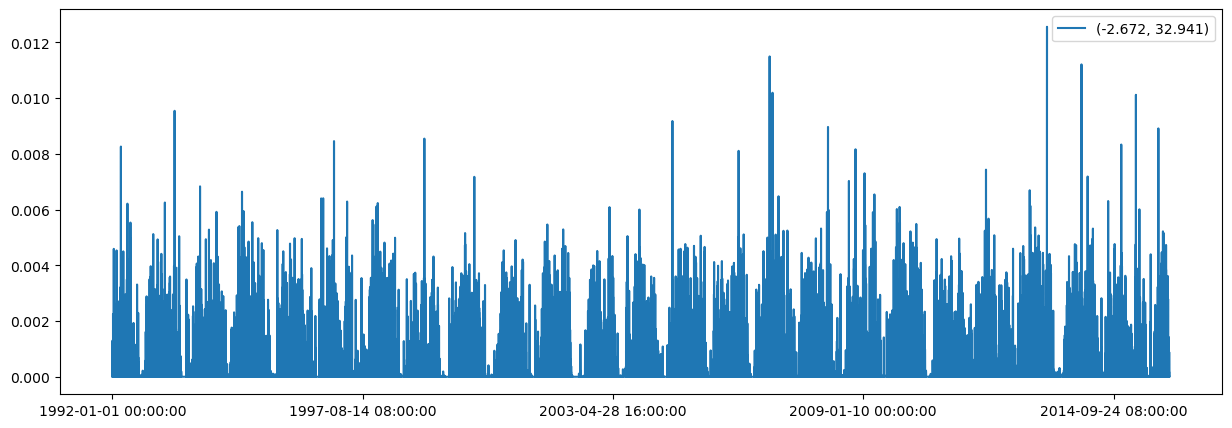

In [43]:
# plot tp
ltm['tp'].plot(figsize=(15,5))

<Axes: >

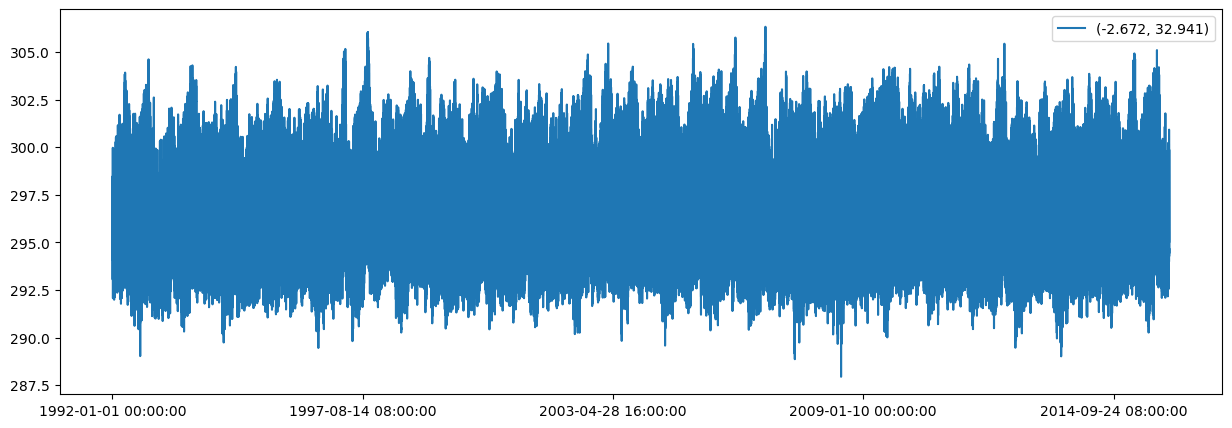

In [44]:
# plot t2m
ltm['t2m'].plot(figsize=(15,5))
#master_tab.t2m.plot(figsize=(15,5))

In [ ]:
# os.chdir('/Users/jphuong/Observatory')
# import ogh
# os.chdir('/Users/jphuong/Observatory/tutorials/netcdf adaptations')

In [46]:
import cftime

# reference date cutoff
ref_date = cftime.DatetimeProlepticGregorian(2010, 1, 1, 0, 0, 0, 0, has_year_zero=True)

prior_period = ltm['master_tab'][ltm['master_tab'].index <= ref_date]
future_period = ltm['master_tab'][ltm['master_tab'].index > ref_date]


In [47]:

pd.DataFrame(prior_period.tp.quantile([0, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 1])).T

,0.00,0.05,0.25,0.50,0.75,0.90,0.95,1.00
tp,0.0,0.0,0.0,0.0,0.000065,0.000399,0.000929,0.011493


In [48]:
pd.DataFrame(future_period.tp.quantile([0, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 1])).T

,0.00,0.05,0.25,0.50,0.75,0.90,0.95,1.00
tp,0.0,0.0,0.0,2.258702e-07,0.000075,0.000447,0.001033,0.012557


<Axes: >

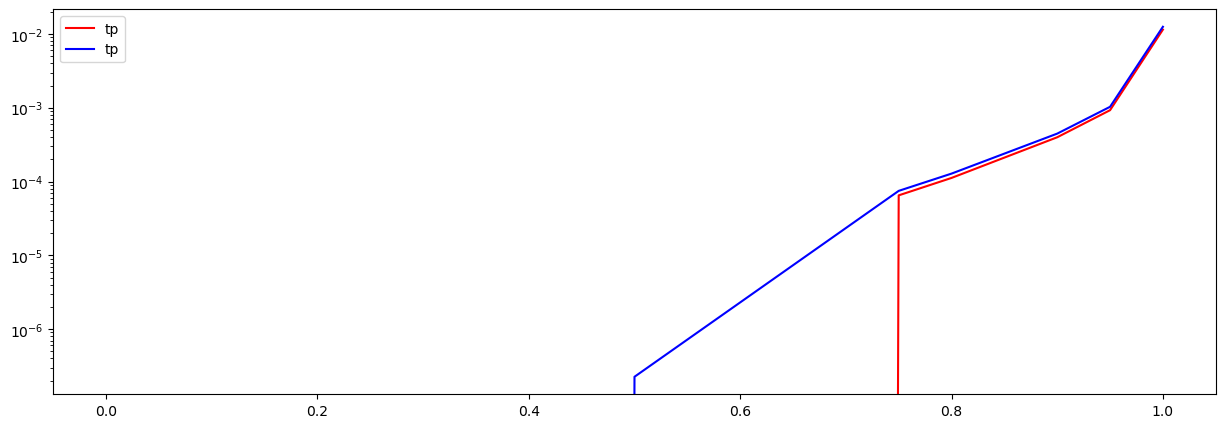

In [51]:
# test plot
fig, ax1 = plt.subplots(figsize=(15,5))
plt.yscale('log')

pd.DataFrame(prior_period.tp.quantile([0, 0.05, 0.25, 0.5, 0.75, .8, 0.90, 0.95, 1]))\
    .plot(kind='line', color='red', ax=ax1)

pd.DataFrame(future_period.tp.quantile([0, 0.05, 0.25, 0.5, 0.75, .8, 0.90, 0.95, 1]))\
    .plot(kind='line', color='blue', ax=ax1)


In [ ]:
## 4) Consider 7-day moving average



In [ ]:
import dask as da


In [ ]:
master_tab

In [ ]:



#vardf_list = [eachvardf for eachvardf in df_dict.keys() if eachvardf.endswith(gridclimname)]

In [ ]:
# %%time
# ltm = ogh.gridclim_dict(mappingfile=mappingfile1,
#                         metadata=meta_file,
#                         dataset='dailywrf_salathe2014',
#                         subset_start_date=dr[0],
#                         subset_end_date=dr[1],
#                         df_dict=ltm)